Here, we fit PLS models specifically to the subset of test conditions in a given fold, which will be used in downstream analyses instead of the global PLS fit in Notebook 04. The response is now the condition (cell type + perturbation) rather than perturbation. 

We ensure that the Q2Y p-value is less than or equal to 0.05 for all PLS model fits. 

In [23]:
import os
from contextlib import contextmanager
import copy
import warnings
import sys

from tqdm import trange

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(1, '../.')
from McCauley_utils import all_data

sys.path.insert(1, '../../.') 
from notebook_utils import get_split

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls

In [2]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)

In [3]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data


In [4]:
def clear_adata(adata):
    for k in copy.deepcopy(adata.obsm.keys()):
        del adata.obsm[k]
    for k in copy.deepcopy(adata.varm.keys()):
        del adata.varm[k]
    for k in copy.deepcopy(adata.obsp.keys()):
        del adata.obsp[k]
    
    return adata

@contextmanager
def suppress_all_output():
    """
    Suppress stdout, stderr, warnings, tqdm, and most parallel chatter.
    """
    # save originals
    old_stdout = sys.stdout
    old_stderr = sys.stderr

    try:
        # redirect stdout / stderr
        sys.stdout = open(os.devnull, 'w')
        sys.stderr = open(os.devnull, 'w')

        # silence warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            # silence tqdm globally
            os.environ["TQDM_DISABLE"] = "1"

            yield

    finally:
        # restore
        sys.stdout.close()
        sys.stderr.close()
        sys.stdout = old_stdout
        sys.stderr = old_stderr

        os.environ.pop("TQDM_DISABLE", None)

In [34]:
# as in Notebook 04
csw = {
    'max_components': 25 ,
    'metric': 'accuracy', 
    'method': 'elbow', 
    'n_folds': 5, 
    'seed': 888
}

assessment_kwargs = {
    'n_perm': 100, 
    'get_q2_pval': True, 
    'get_r2_pval': False, 
    'get_accuracy_pval': False,
    'n_folds': 5, 
    'seed': 888
}

def condition_specific_PLS(fold, n_components = None):
    """Fits PLS models specific to a fold test condition. Y-block is now condition rather than perturbation."""

    split = get_split(fold, author)
    test_conds = split['test_conds']

    test_cond_mask = tf_adata.obs.condition.isin(test_conds)
    tf_adata_test = tf_adata[test_cond_mask,:].copy()

    tf_adata_test = clear_adata(tf_adata_test)
    
    # hacky way of running ls.pls_da, that only allows pert_col or cat_col
    tf_adata_test.obs[pert_col] = tf_adata_test.obs['condition'].copy()

    with suppress_all_output():
        models, X_pls = ls.pls_da(
            adata = tf_adata_test, 
            n_components = n_components, 
            assess = True, 
            enc_X = None, enc_Y = None, control_confounders = None, 
            separate_by = 'perturbation', # actually separating by condition 
            pert_col = pert_col, 
            cat_col = cat_col, 
            component_selection_kwargs = csw, 
            assessment_kwargs = assessment_kwargs, 
            n_cores = n_cores, 
            verbose = False
        )


    pls_model = models['pls_model']

    q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
    assert q2y_pval <= 0.05, 'The fit model is not significant for fold: {}'.format(fold)
    X_pls_transform = pls_model.transform(tf_adata_test.X)
    assert np.allclose(X_pls_transform, X_pls), 'Something is missing between model fit and transform'
    
    return pls_model

In [32]:
condition_specific_pls_models = {}
for fold in trange(5):
    condition_specific_pls_models[fold] = condition_specific_PLS(fold)

100%|█████████████████████████████████████████████| 5/5 [01:14<00:00, 14.93s/it]


Fold: 1 | 5 components | Q2Y 0.752 (p = 9.90E-03)
Fold: 2 | 3 components | Q2Y 0.859 (p = 9.90E-03)
Fold: 3 | 4 components | Q2Y 0.910 (p = 9.90E-03)
Fold: 4 | 2 components | Q2Y 0.443 (p = 9.90E-03)
Fold: 5 | 2 components | Q2Y 0.888 (p = 9.90E-03)


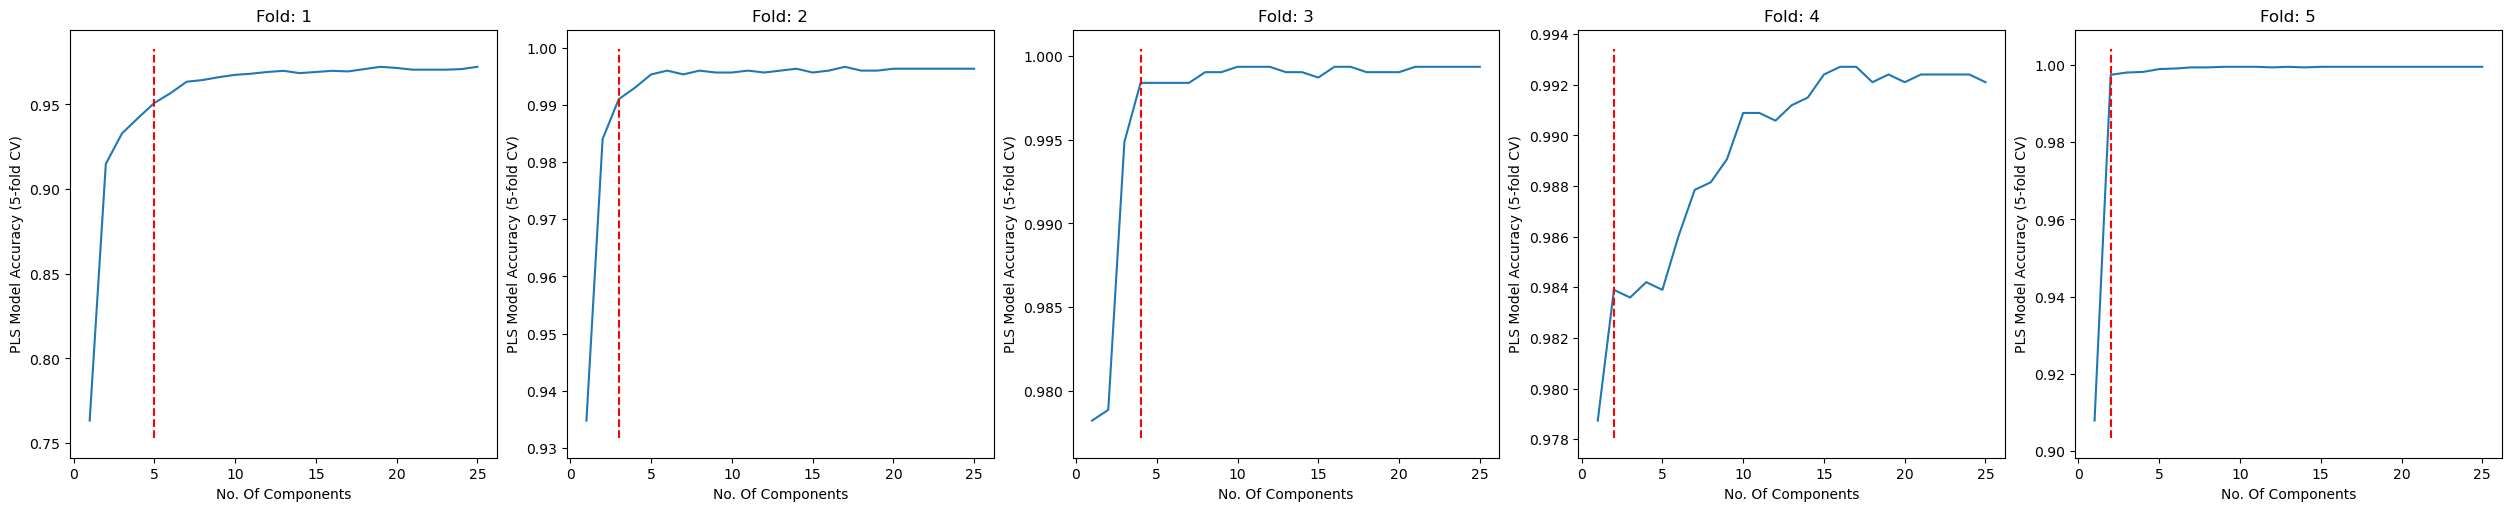

In [33]:
fig, ax = plt.subplots(ncols = 5, figsize = (25, 5), constrained_layout = True)

for fold in range(5):
    pls_model = condition_specific_pls_models[fold]
    n_components = pls_model.n_components
    q2y = pls_model.assessment_metrics['Q2Y']['value']
    q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
    print('Fold: {} | {} components | Q2Y {:.3f} (p = {:.2E})'.format(fold+1, n_components, q2y, q2y_pval))
    
    
    sns.lineplot(y = pls_model.metric_per_component, x = range(1, len(pls_model.metric_per_component) + 1), ax = ax[fold])
    ymin, ymax = ax[fold].get_ylim()
    ax[fold].vlines(x = pls_model.n_components, ymin = ymin, ymax = ymax, #label = 'Selected No. of Components',
              color = 'red', linestyle = '--'
             )
    ax[fold].set_xlabel('No. Of Components')
    ax[fold].set_ylabel('PLS Model Accuracy (5-fold CV)')
    ax[fold].set_title('Fold: {}'.format(fold + 1))


**Note, for fold 4, the automated elbow selection selects 2 components given the shape of the accuracy curve. After visual observation, we instead manually set it to 10**. 

In [40]:
fold = 3
condition_specific_pls_models[fold] = condition_specific_PLS(fold = fold, n_components = 10)

pls_model = condition_specific_pls_models[fold]
n_components = pls_model.n_components
q2y = pls_model.assessment_metrics['Q2Y']['value']
q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
print('Fold: {} | {} components | Q2Y {:.3f} (p = {:.2E})'.format(fold+1, n_components, q2y, q2y_pval))

Fold: 4 | 10 components | Q2Y 0.570 (p = 9.90E-03)


In [41]:
io.write_pickled_object(
    condition_specific_pls_models,
    os.path.join(data_path, 'interim', '{}_test_condition_PLS_models.pickle')
)